# RetailLens · Notebook 2 — RFM Feature Engineering & Customer Segmentation

## What this notebook does
1. Build the **RFM table** — one row per customer, three features: Recency, Frequency, Monetary
2. Prepare features for machine learning (log transform + scaling)
3. Use **K-Means clustering** to group customers into segments
4. Choose the right number of clusters using the **silhouette score**
5. Label clusters with business-meaningful names
6. Visualise the segments so we understand who they are

## What is RFM?
RFM is one of the most well-known frameworks in marketing analytics.
It asks three questions about every customer:

| Letter | Question | Intuition |
|---|---|---|
| **R**ecency | How long ago did they last buy? | Recent buyers are more likely to buy again |
| **F**requency | How many times have they bought? | Frequent buyers are loyal |
| **M**onetary | How much have they spent in total? | High spenders are your most valuable customers |

By scoring every customer on these three dimensions, we can group them into
meaningful segments — and treat each group differently.

### Step 1 - Import libraries 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import warnings


warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [6]:
# Load clean data
df = pd.read_csv('../data/clean_data.csv', parse_dates=['InvoiceDate'])
print(f"Loaded: {len(df):,} rows, {df['Customer ID'].nunique():,} unique customers")
df.head(3)

Loaded: 805,549 rows, 5,878 unique customers


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalRevenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12


### Step 2- Build the RFM table
**Snapshot date:** We pick a reference point — one day after the last transaction in the dataset.
This is the date from which we measure "recency". We add 1 day so that even the
most recent customer has a recency of at least 1 (not 0).

**Aggregation logic:**
- `Recency` = (snapshot_date - last InvoiceDate) in days → smaller = more recent
- `Frequency` = count of *unique* Invoice numbers (not row count — one order can have many rows)
- `Monetary` = sum of all TotalRevenue for that customer

In [7]:
# Find the latest transaction date in the dataset
last_transaction_date = df['InvoiceDate'].max()

# Add 1 day to the latest transaction date
snapshot_date = last_transaction_date + pd.Timedelta(days=1)

print(f"Snapshot Date: {snapshot_date.date()}")

# Print the last transaction date for checking
print(f"Last transaction was: {last_transaction_date.date()}")

Snapshot Date: 2011-12-10
Last transaction was: 2011-12-09


In [8]:
# Build RFM table — one row for each customer
rfm = df.groupby('Customer ID').agg(

    # Recency:
    # How many days since the customer's last purchase
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),

    # Frequency:
    # How many unique invoices/orders the customer has
    # unique orders, NOT row count
    Frequency=('Invoice', 'nunique'),

    # Monetary:
    # Total money spent by the customer
    Monetary=('TotalRevenue', 'sum')

).reset_index()

# the size of the RFM table
print(f"RFM table shape: {rfm.shape}  (one row per customer)")
print()
print("First 5 rows:")
rfm.head()

RFM table shape: (5878, 4)  (one row per customer)

First 5 rows:


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [9]:
# Statistical summary of RFM
print("RFM summary statistics:")
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

RFM summary statistics:


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,3018.62
std,209.34,13.01,14737.73
min,1.00,1.00,2.95
25%,26.00,1.00,348.76
50%,96.00,3.00,898.92
75%,380.00,7.00,2307.09
max,739.00,398.00,608821.65


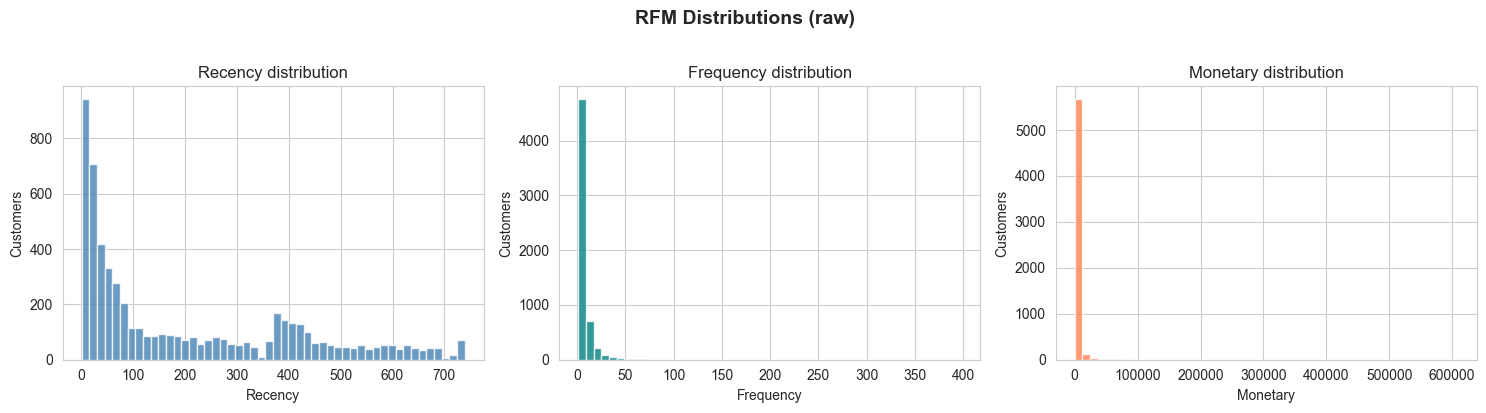

A few customers have extremely high values that would dominate clustering.


In [11]:
# Define RFM features to visualize
rfm_features = ['Recency', 'Frequency', 'Monetary']

# Define custom colors for each RFM feature
colors = ['steelblue', 'teal', 'coral']

# Initialize a 1x3 subplot grid for side-by-side comparison
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

# Generate histogram for each RFM feature
for ax, feature, color in zip(axes, rfm_features, colors):

    # Plot frequency distribution of the current feature
    ax.hist(
        rfm[feature],
        bins=50,
        color=color,
        alpha=0.8,
        edgecolor='white'
    )

    # Add subplot-level metadata
    ax.set_title(f'{feature} distribution')
    ax.set_xlabel(feature)
    ax.set_ylabel('Customers')

# Add figure-level title
plt.suptitle(
    'RFM Distributions (raw)',
    y=1.02,
    fontsize=14,
    fontweight='bold'
)

# Optimize layout spacing
plt.tight_layout()

# Display plot
plt.show()
print("A few customers have extremely high values that would dominate clustering.")

### Step 3 - Preapre features for K-Means

K-Means requires features to be prepared before clustering because it uses
Euclidean distance. Features with extreme skew or larger scales can dominate
the distance calculation and produce poor clusters.

## Requirement 1: Reduce extreme skew
Frequency and Monetary are often highly right-skewed, meaning most customers
have low values while a few customers have very large values.
These extreme values can strongly influence K-Means clustering.

Fix:
Apply log transformation using np.log1p().
np.log1p(x) means log(1 + x).
This compresses large values while keeping smaller values meaningful.
The +1 prevents log(0) errors if any customer has a value of 0.

## Requirement 2: Put all features on the same scale
Even after log transformation, Recency, Frequency, and Monetary may still
have different ranges.
K-Means is distance-based, so features with larger numeric ranges can have
more influence than smaller-range features.

Fix:
Apply StandardScaler.
StandardScaler transforms each feature to have mean = 0 and standard deviation = 1.
This makes all RFM features comparable, so each contributes fairly to clustering.

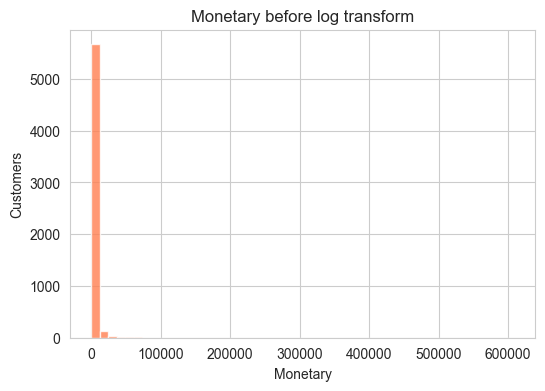

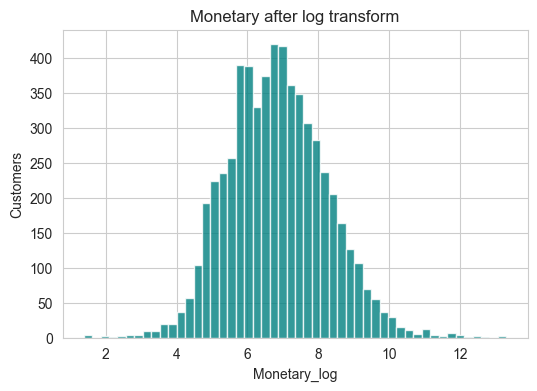

In [12]:
# Copy original RFM data
rfm_model = rfm.copy()

# Create log-transformed Monetary column
rfm_model['Monetary_log'] = np.log1p(rfm_model['Monetary'])

# Plot Monetary before log transformation
plt.figure(figsize=(6, 4))
plt.hist(rfm_model['Monetary'], bins=50, color='coral', alpha=0.8)
plt.title('Monetary before log transform')
plt.xlabel('Monetary')
plt.ylabel('Customers')
plt.show()

# Plot Monetary after log transformation
plt.figure(figsize=(6, 4))
plt.hist(rfm_model['Monetary_log'], bins=50, color='teal', alpha=0.8)
plt.title('Monetary after log transform')
plt.xlabel('Monetary_log')
plt.ylabel('Customers')
plt.show()

In [13]:
# Select columns for clustering
features = ['Recency', 'Frequency', 'Monetary_log']

# Create the scaler
scaler = StandardScaler()

# Learn the mean and standard deviation from the data
scaler.fit(rfm_model[features])

# Apply the scaling transformation
rfm_scaled = scaler.transform(rfm_model[features])

# Convert result into DataFrame
scaled_df = pd.DataFrame(rfm_scaled, columns=features)

# Check mean and standard deviation
print(scaled_df.mean().round(3))
print(scaled_df.std().round(3))

Recency        -0.0
Frequency      -0.0
Monetary_log   -0.0
dtype: float64
Recency         1.0
Frequency       1.0
Monetary_log    1.0
dtype: float64


In [14]:
print("All features now have mean ≈ 0 and std = 1.0 ✓")

All features now have mean ≈ 0 and std = 1.0 ✓


## Step 4 — Choose the optimal number of clusters (k)

K-Means requires you to specify k (number of clusters) upfront.
How do we know the right number?

### Silhouette Score
The silhouette score measures how well each customer fits into its assigned cluster,
compared to the next-nearest cluster.

- Score = +1 → customer is perfectly in the right cluster
- Score = 0  → customer is on the boundary between two clusters
- Score = -1 → customer is probably in the wrong cluster

**We test k = 2 to 8 and pick the k with the highest silhouette score.**

### Why not use the Elbow Method?
The elbow method plots inertia (within-cluster sum of squares) vs k and looks for
an "elbow" in the curve. It's subjective and often unclear. Silhouette score gives
a direct measure of cluster quality — we prefer it here.

In [15]:
# Create an empty list to store results for each k.
# We use a list because each loop creates one complete row:
# [k, silhouette_score, inertia]
# Later, this list can be easily converted into a pandas DataFrame.
results = []

# Test k values from 2 to 8.
# k = number of clusters.
# We start from 2 because silhouette score needs at least 2 clusters.
for k in range(2, 9):

    # Create a K-Means model for the current k value.
    # random_state=42 makes results reproducible.
    # n_init=10 runs K-Means 10 times and keeps the best result.
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit the model on the scaled RFM data and assign each customer to a cluster.
    labels = model.fit_predict(rfm_scaled)

    # Calculate silhouette score.
    # Higher silhouette score means better cluster separation.
    score = silhouette_score(rfm_scaled, labels)

    # Store one row of results:
    # k = number of clusters
    # score = silhouette score
    # model.inertia_ = within-cluster sum of squared distances
    results.append([k, score, model.inertia_])

# Convert the list of results into a DataFrame.
# This makes the results easier to read, sort, filter, and analyse.
results_df = pd.DataFrame(
    results,
    columns=['k', 'silhouette_score', 'inertia']
)

# Display all tested k values with their evaluation metrics.
print(results_df)

# Find the row where silhouette_score is the highest.
# idxmax() returns the index position of the maximum silhouette score.
best_row = results_df.loc[results_df['silhouette_score'].idxmax()]

# Extract the best k value from that row.
# int() converts it from a numeric DataFrame value into a normal integer.
best_k = int(best_row['k'])

# Print the selected best number of clusters.
print(f"Best k = {best_k}")

   k  silhouette_score       inertia
0  2          0.427027  11114.365536
1  3          0.442586   8016.395547
2  4          0.410916   5473.307848
3  5          0.390435   4431.417253
4  6          0.387048   3667.855527
5  7          0.386159   3120.775931
6  8          0.369774   2605.162430
Best k = 3


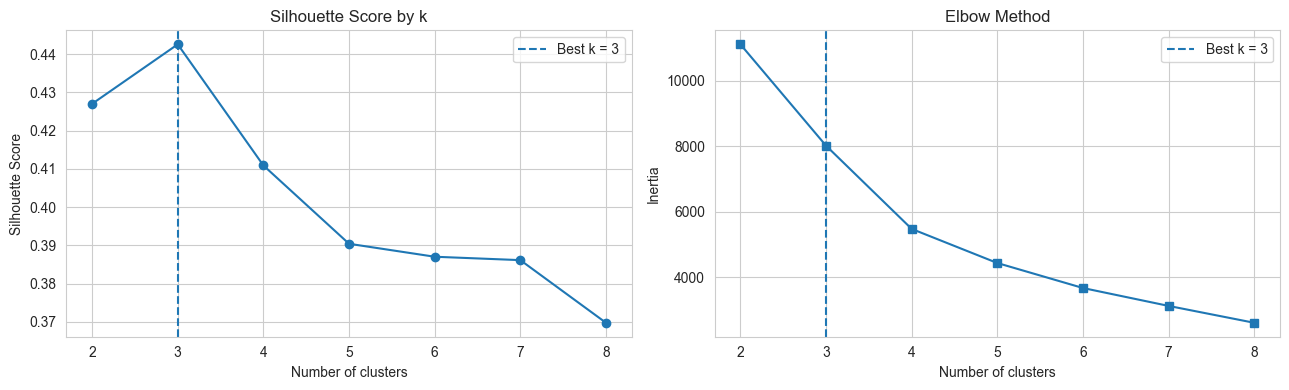

In [ ]:
# Create two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# First chart: silhouette score
axes[0].plot(results_df['k'], results_df['silhouette_score'], marker='o')
axes[0].axvline(best_k, linestyle='--', label=f'Best k = {best_k}')
axes[0].set_title('Silhouette Score by k')
axes[0].set_xlabel('Number of clusters')
axes[0].set_ylabel('Silhouette Score')
axes[0].legend()

# Second chart: inertia
axes[1].plot(results_df['k'], results_df['inertia'], marker='s')
axes[1].axvline(best_k, linestyle='--', label=f'Best k = {best_k}')
axes[1].set_title('Elbow Method')
axes[1].set_xlabel('Number of clusters')
axes[1].set_ylabel('Inertia')
axes[1].legend()

# Fix spacing and show plots
plt.tight_layout()
plt.show()


# This code visualises how good each k value is.
# The Silhouette Score chart is used to choose the best k.
# The Inertia chart is shown as a reference to understand the Elbow Method.

### Step 5 — Train the final K-Means model

With k=3 confirmed, we train the final model and assign every customer a cluster label.

In [17]:
# Train the final K-Means model using the best number of clusters found earlier.
# best_k was selected based on the highest silhouette score.
km_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

# Fit the final model on the scaled RFM data and assign each customer to a cluster.
# fit_predict() trains the model and returns the cluster label for each customer.
# The cluster label is added back to the original rfm DataFrame.
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)


# Create cluster profiles using the original RFM values.
# This helps us interpret what each cluster means in business terms.
profile = rfm.groupby('Cluster').agg(

    # Count how many customers are in each cluster
    Count=('Customer ID', 'count'),

    # Average number of days since last purchase
    Recency=('Recency', 'mean'),

    # Average number of purchases per customer
    Frequency=('Frequency', 'mean'),

    # Average customer spending
    Monetary=('Monetary', 'mean')

).round(1)


# Print the cluster profile table before assigning business names.
print("Raw cluster profiles (before naming):")
print(profile)

# Print a blank line for cleaner output.
print()

# Print a simple guide to help interpret cluster behaviour.
print("Interpretation guide:")
print("  Low Recency + High Frequency + High Monetary  →  Best customers")
print("  High Recency + Low Frequency + Low Monetary   →  Lost/Inactive customers")

Raw cluster profiles (before naming):
         Count  Recency  Frequency  Monetary
Cluster                                     
0         2283    418.1        1.9     543.4
1         3571     64.0        8.1    3714.7
2           24     21.4      152.1  134898.1

Interpretation guide:
  Low Recency + High Frequency + High Monetary  →  Best customers
  High Recency + Low Frequency + Low Monetary   →  Lost/Inactive customers


In [18]:
# Map cluster numbers to business-meaningful names
# We read the profiles above and assign names based on what each cluster looks like

# Create a dictionary to map numeric K-Means cluster labels
# into meaningful business segment names.
# IMPORTANT:
# These names should be assigned after checking the cluster profile table.
# Cluster numbers are not ranked automatically.
cluster_names = {
    0: 'Lost / Inactive',
    1: 'Loyal Customers',
    2: 'Champions'
}

# Add a new Segment column by replacing cluster numbers with segment names.
# Example:
# Cluster 0 becomes "Lost / Inactive"
# Cluster 1 becomes "Loyal Customers"
# Cluster 2 becomes "Champions"
rfm['Segment'] = rfm['Cluster'].map(cluster_names)

# Show how many customers belong to each segment.
# This helps us understand the size of each customer group.
print("Segment distribution:")
print(rfm['Segment'].value_counts())

# Add a blank line for cleaner output.
print()

# Create a segment profile table.
# This groups customers by Segment and calculates:
# Count      = number of customers in each segment
# Recency    = average days since last purchase
# Frequency  = average number of purchases
# Monetary   = average customer spend
segment_profile = (
    rfm.groupby('Segment')
       .agg(
           Count=('Customer ID', 'count'),
           Recency=('Recency', 'mean'),
           Frequency=('Frequency', 'mean'),
           Monetary=('Monetary', 'mean')
       )
       .round(1)
)

# Display the average RFM profile for each segment.
# This helps validate whether the segment names make business sense.
print("Segment profiles:")
display(segment_profile)

Segment distribution:
Segment
Loyal Customers    3571
Lost / Inactive    2283
Champions            24
Name: count, dtype: int64

Segment profiles:


,Count,Recency,Frequency,Monetary
Segment,,,,
Champions,24,21.4,152.1,134898.1
Lost / Inactive,2283,418.1,1.9,543.4
Loyal Customers,3571,64.0,8.1,3714.7


### Step 6 — Visualise the segments

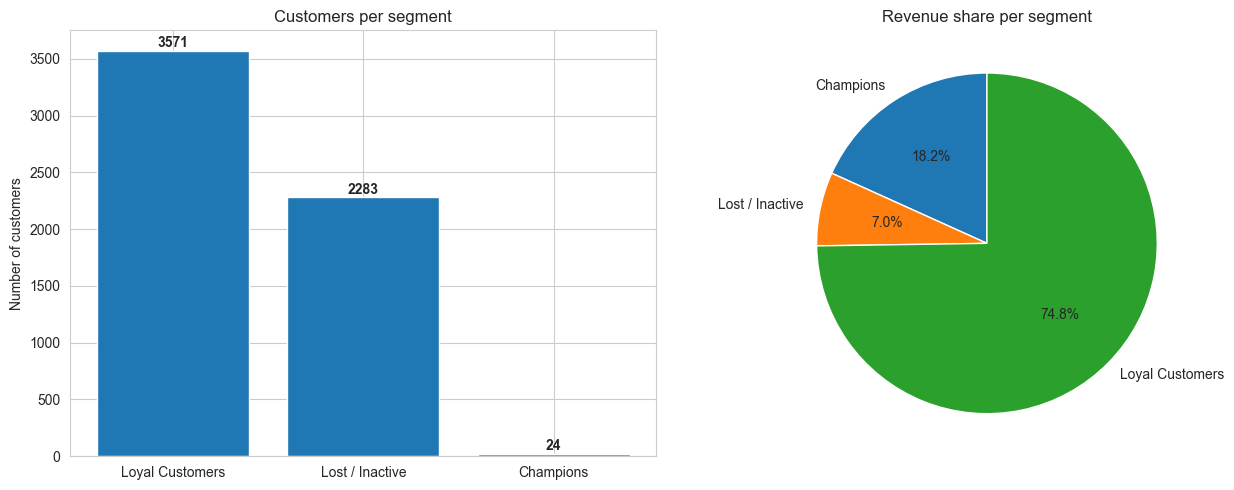

In [20]:
# Count customers per segment
counts = rfm['Segment'].value_counts()

# Calculate total revenue per segment
revenue = rfm.groupby('Segment')['Monetary'].sum()

# Create two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].bar(counts.index, counts.values)
axes[0].set_title('Customers per segment')
axes[0].set_ylabel('Number of customers')

# Add count labels above bars
for i, count in enumerate(counts.values):
    axes[0].text(i, count + 30, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    revenue.values,
    labels=revenue.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Revenue share per segment')

plt.tight_layout()
plt.show()

In [21]:
# ── RFM scatter: Recency vs Monetary, sized by Frequency ─────────────────────

# Filter out very high spenders so the scatter plot remains readable
plot_data = rfm[rfm['Monetary'] < 100000]

# Create interactive scatter plot
fig = px.scatter(
    plot_data,
    x='Recency',
    y='Monetary',
    color='Segment',
    size='Frequency',
    color_discrete_map=seg_colors,
    hover_data=['Customer ID', 'Frequency', 'Monetary'],
    labels={
        'Recency': 'Recency (days)',
        'Monetary': 'Total Spend (£)'
    },
    title='Customer Segments — Recency vs Spend (bubble size = order frequency)',
    opacity=0.7
)

# Set chart height
fig.update_layout(height=500)

# Display plot
fig.show()

# Print interpretation guide
print("Notice:")
print("  Champions → upper-left: bought recently, spent most")
print("  Lost/Inactive → bottom-right: haven't bought in a long time, spent little")
print("  Loyal → middle: recent-ish, moderate spend")

Notice:
  Champions → upper-left: bought recently, spent most
  Lost/Inactive → bottom-right: haven't bought in a long time, spent little
  Loyal → middle: recent-ish, moderate spend


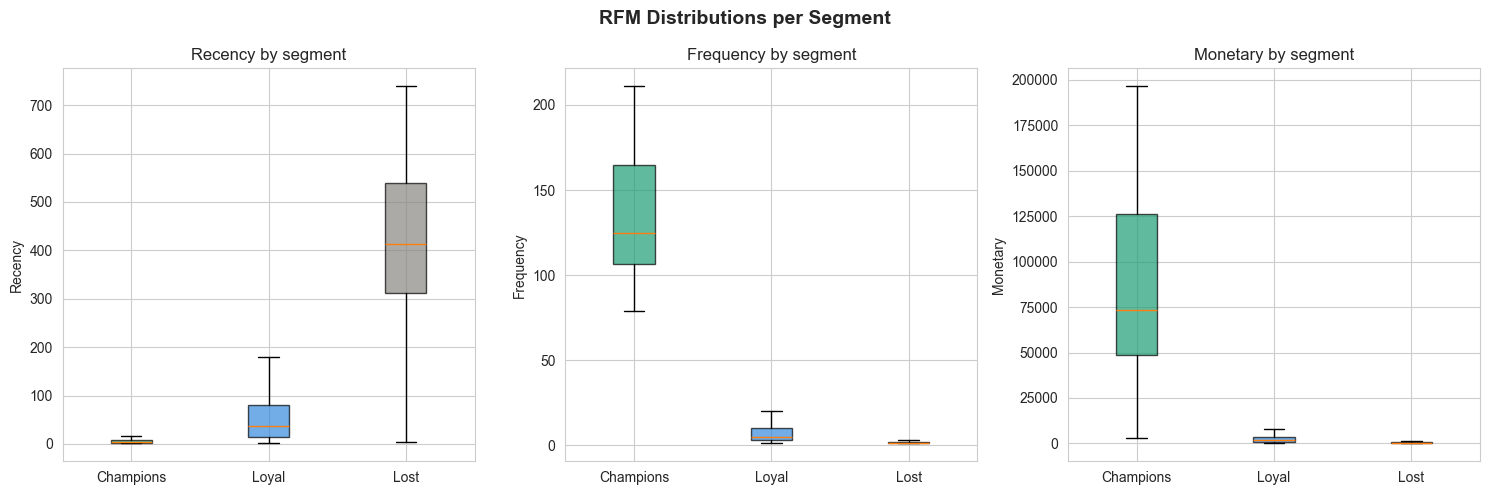

In [23]:
# ── Box plots: RFM distributions per segment ──────────────────────────────────

# Create a figure with 1 row and 3 columns of subplots.
# Each subplot will show one RFM feature:
# axes[0] = Recency
# axes[1] = Frequency
# axes[2] = Monetary
fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# Loop through each subplot axis and each RFM column at the same time.
# zip() pairs:
# axes[0] with 'Recency'
# axes[1] with 'Frequency'
# axes[2] with 'Monetary'
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):

    # Create a list of values for the current RFM feature,
    # separated by customer segment.
    #
    # For example, when col = 'Recency':
    # data_by_seg = [
    #     Recency values for Champions,
    #     Recency values for Loyal Customers,
    #     Recency values for Lost / Inactive
    # ]
    data_by_seg = [
        rfm[rfm['Segment'] == s][col].values
        for s in ['Champions', 'Loyal Customers', 'Lost / Inactive']
    ]

    # Create a box plot for the current feature.
    #
    # labels = names shown on the x-axis
    # patch_artist=True allows us to fill the boxes with colours
    # showfliers=False hides outlier dots so the chart is easier to read
    bp = ax.boxplot(
        data_by_seg,
        labels=['Champions', 'Loyal', 'Lost'],
        patch_artist=True,
        showfliers=False
    )

    # Colour each box according to the segment.
    # bp['boxes'] contains the box objects created by ax.boxplot().
    for patch, color in zip(bp['boxes'], ['#1D9E75', '#378ADD', '#888780']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Add a title to the current subplot.
    ax.set_title(f'{col} by segment')

    # Add y-axis label.
    ax.set_ylabel(col)


# Add one main title above all three plots.
plt.suptitle(
    'RFM Distributions per Segment',
    fontsize=14,
    fontweight='bold'
)

# Adjust spacing so titles and labels do not overlap.
plt.tight_layout()

# Display the final figure.
plt.show()

In [25]:
# Save the segmented RFM table

output_path = '../data/rfm_segments.csv'

# Export DataFrame to CSV.
# index=False prevents pandas from writing the row index as an extra CSV column.
rfm.to_csv(output_path, index=False)

# Confirm export and show saved columns.
print(f"Saved: {output_path}")
print(f"Rows saved: {len(rfm):,}")
print(f"Columns saved: {rfm.columns.tolist()}")

Saved: ../data/rfm_segments.csv
Rows saved: 5,878
Columns saved: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']


In [ ]:
# Notebook Summary:
# - Built an RFM table using Recency, Frequency, and Monetary values for each customer.
# - Explored RFM distributions and found skewness/outliers, especially in Frequency and Monetary.
# - Prepared data for K-Means by applying log transformation and StandardScaler.
# - Tested different k values using Silhouette Score and trained the final K-Means model.
# - Assigned business segment names, visualised segment performance, and saved rfm_segments.csv.